In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import h5py
import calc_op_em as coe


In [6]:
# Read a model atmosphere from an HDF5 file
filename = '/dat/milic/SUSI_modeling/extended_cube.h5'

# Do a lazy way of reading without putting everything in memory at once: 

f = h5py.File(filename, 'r')
Temp = f['Temperature']
print ("info::shape of the temperature array is: ", Temp.shape)  # Check the shape of the dataset

Pgas = f['Pressure']
ne = f['Electron_density']
LOS_velocity = f['LOS_velocity']
Population_lower_level = f['Population_lower_level']

info::shape of the temperature array is:  (1024, 8333, 401)


In [7]:
# Get me a specific Temperature, Pressure, etc. along the line of sight (LOS)
Temp_los = Temp[0,:,160]
Pgas_los = Pgas[0,:,160]
ne_los = ne[0,:,160]
LOS_velocity_los = LOS_velocity[0,:,160]
Population_lower_level_los = Population_lower_level[0,:,160]
Temp_los.shape

(8333,)

In [10]:
# Now let's import Olivia's functions and calculate the level population that way

import saha_caII as scaII
from astropy import units as u 

In [14]:
# Call the numberdensCa2 function and add units to the quantities
n_caII_lte = scaII.numberdensCa2(Pgas_los * u.g / u.cm/u.s**2, Temp_los * u.K, ne_los * u.cm**-3, verbose=False)[0]

/home/milic/codes/offlimb_3D_modeling/saha_caII.py:33: RuntimeWarning: overflow encountered in exp
  return np.exp(lnZ)


In [15]:
n_caII_lte = np.asarray(n_caII_lte)  # Convert to a regular numpy array if it's not already
print(n_caII_lte.shape)  # Check the shape of the resulting array   

(8333,)


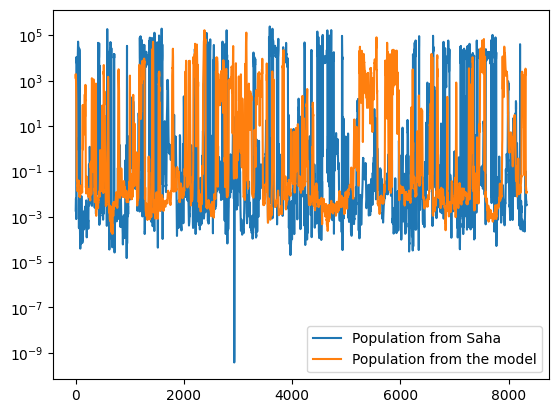

In [18]:
plt.semilogy(n_caII_lte, label='Population from Saha')
plt.semilogy(Population_lower_level_los/1e6, label='Population from the model')
plt.legend()

In [19]:
# Get me a specific Temperature, Pressure, etc. along the whole first slice
Temp_slice = Temp[0,:,:]
Pgas_slice = Pgas[0,:,:]
ne_slice = ne[0,:,:]
LOS_velocity_slice = LOS_velocity[0,:,:]
Population_lower_level_slice = Population_lower_level[0,:,:]
Temp_slice.shape

(8333, 401)

In [20]:
# Call the numberdensCa2 function and add units to the quantities
n_caII_lte_slice = scaII.numberdensCa2(Pgas_slice * u.g / u.cm/u.s**2, Temp_slice * u.K, ne_slice * u.cm**-3, verbose=False)[0]

/home/milic/codes/offlimb_3D_modeling/saha_caII.py:33: RuntimeWarning: overflow encountered in exp
  return np.exp(lnZ)
/home/milic/miniconda3/envs/lw/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/milic/miniconda3/envs/lw/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [21]:
n_caII_lte_slice = np.asarray(n_caII_lte_slice)  # Convert to a regular numpy array if it's not already
print(n_caII_lte_slice.shape)  # Check the shape of the resulting array

(8333, 401)


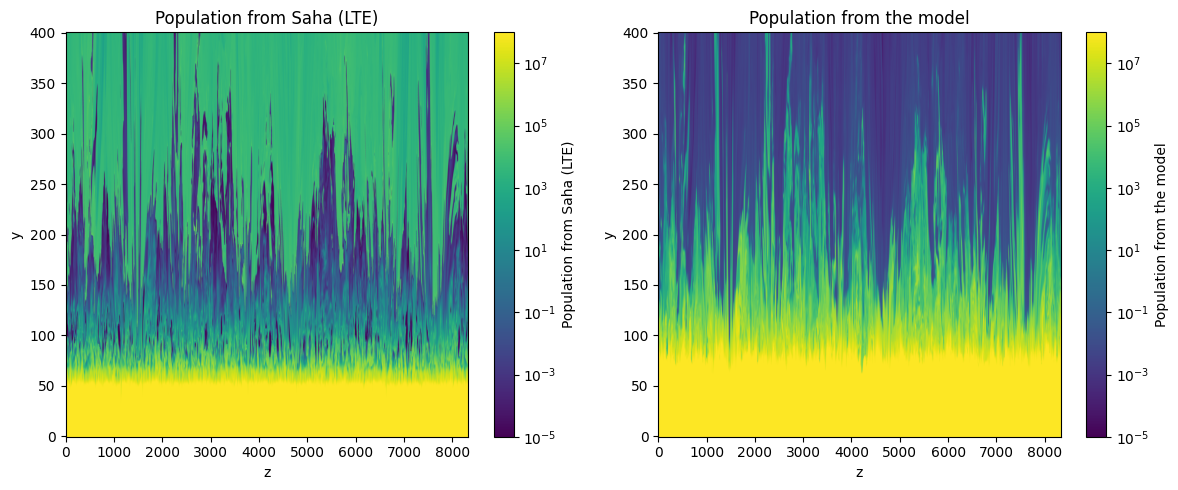

In [ ]:
# Make two plots to compare the y, z distribution of the populations from lte and from the model
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.imshow(n_caII_lte_slice.T, origin='lower', aspect='auto', cmap='viridis', norm='log', vmin=1e-5, vmax=1e8)
plt.colorbar(label='Population from Saha (LTE)')
plt.title('Population from Saha (LTE)')
plt.xlabel('z')
plt.ylabel('y')
plt.subplot(2,1, 2)
plt.imshow(Population_lower_level_slice[:,::-1].T/1e6, origin='lower', aspect='auto', cmap='viridis', norm='log', vmin=1e-5, vmax=1e8)
plt.colorbar(label='Population from the model')
plt.title('Population from the model')
plt.xlabel('z')
plt.ylabel('y')
plt.tight_layout()
plt.show()